100%|██████████| 450/450 [00:49<00:00,  9.16it/s]


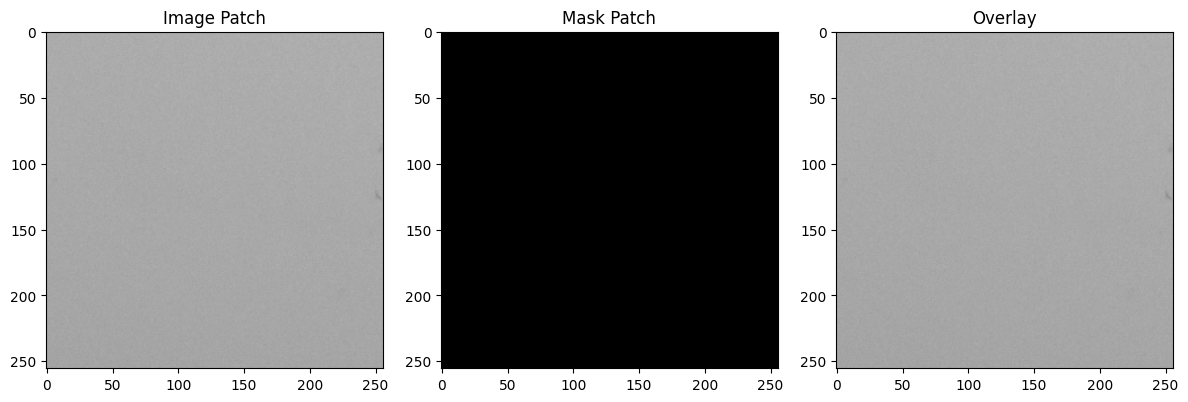

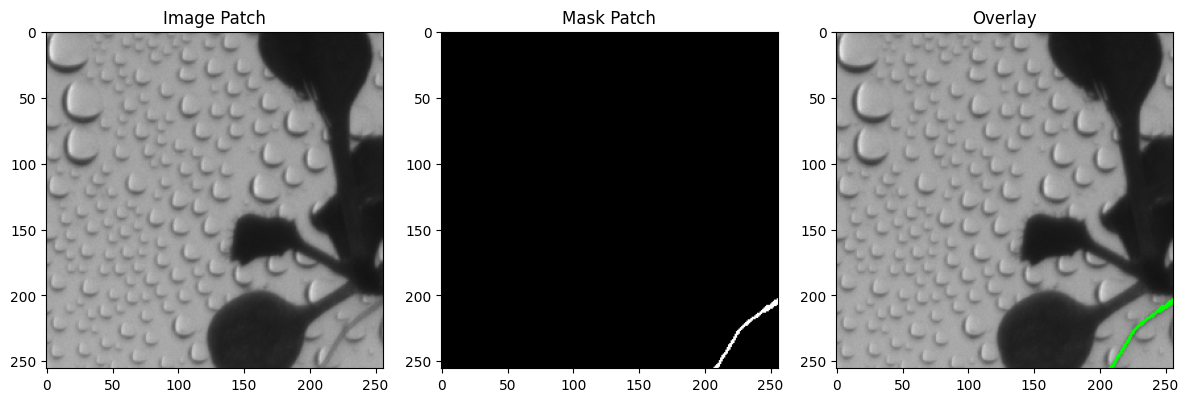

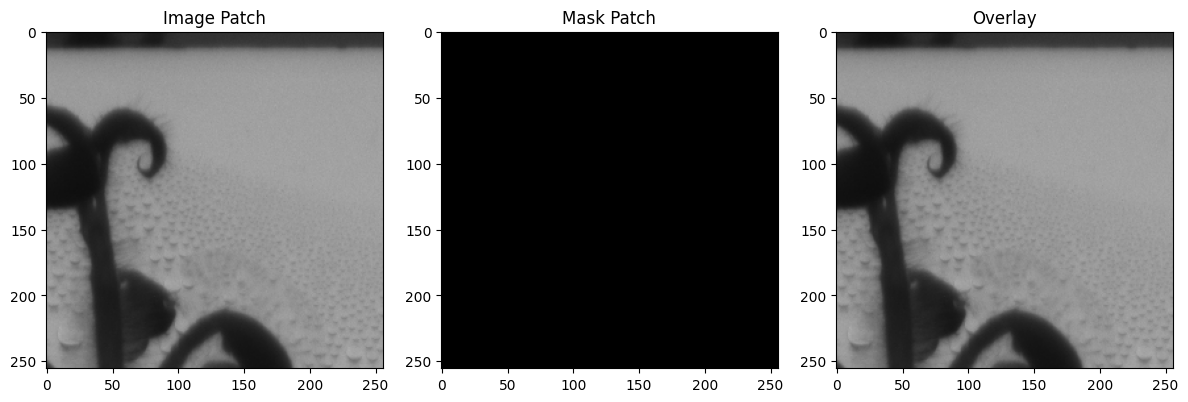

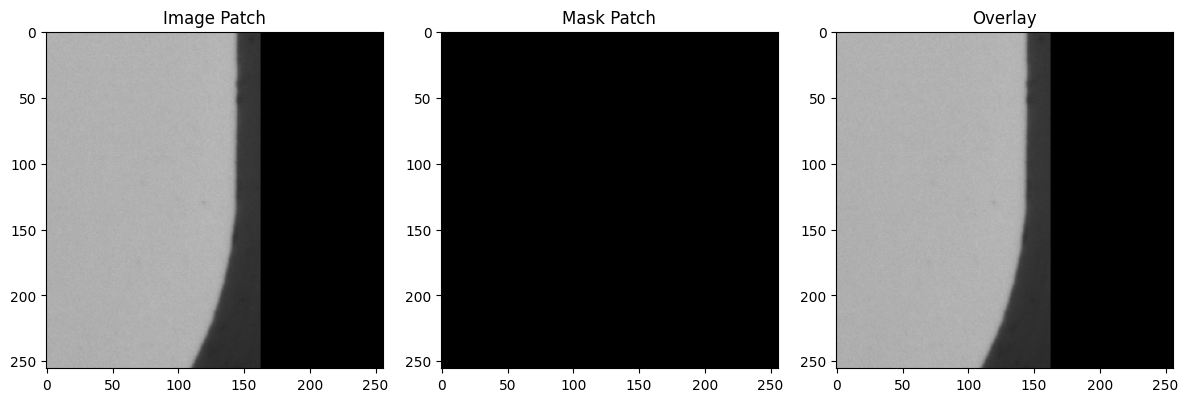

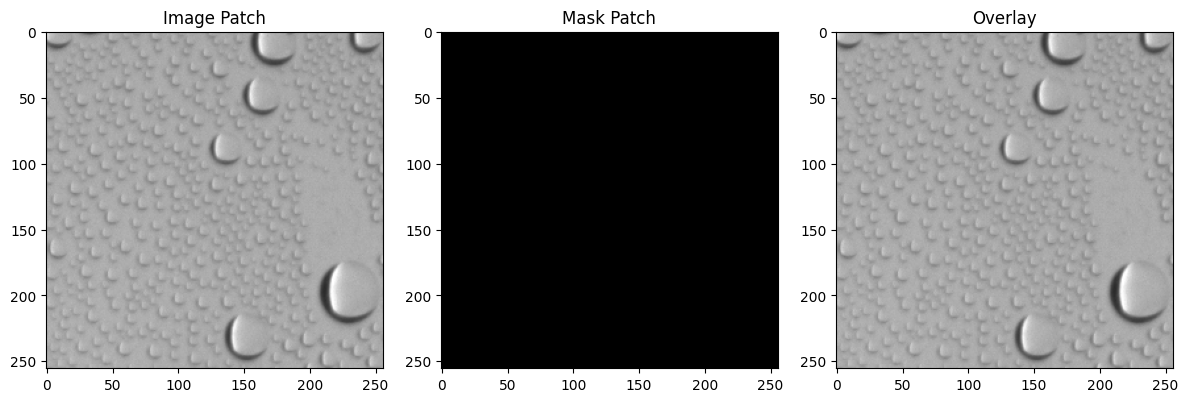

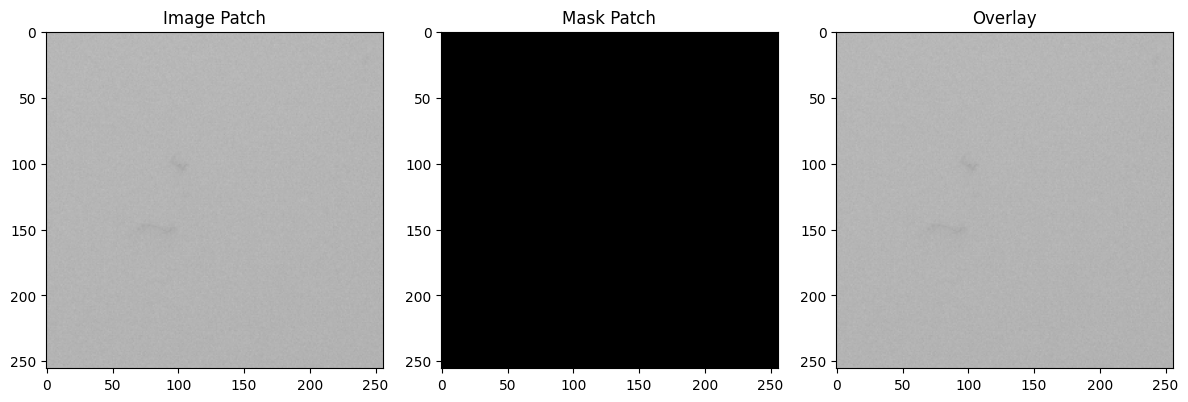

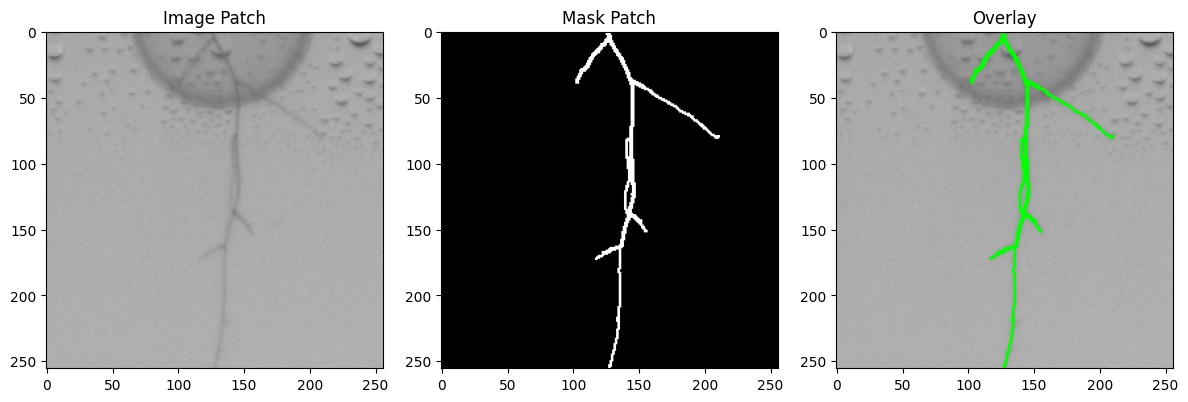

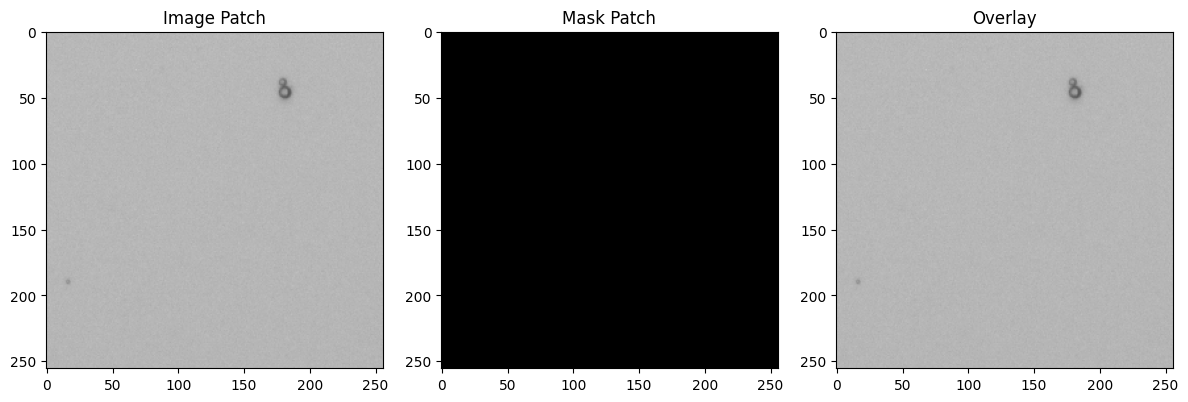

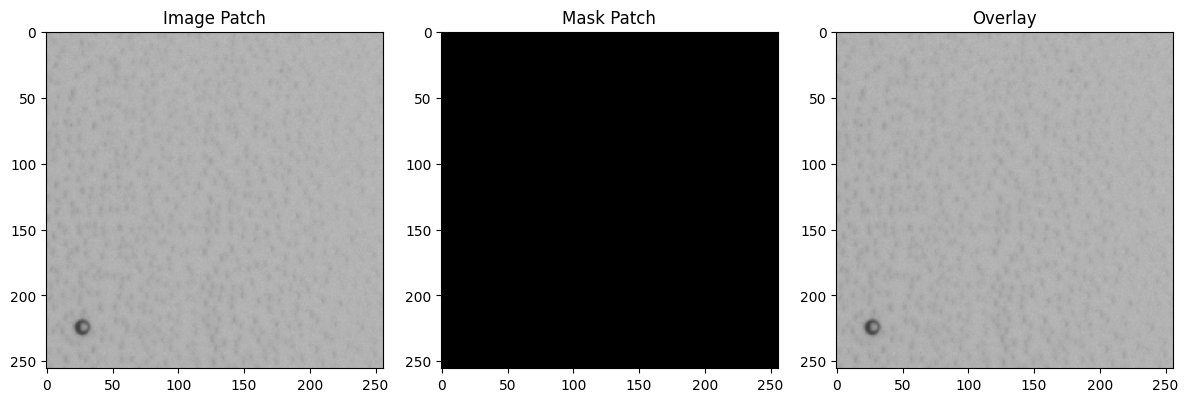

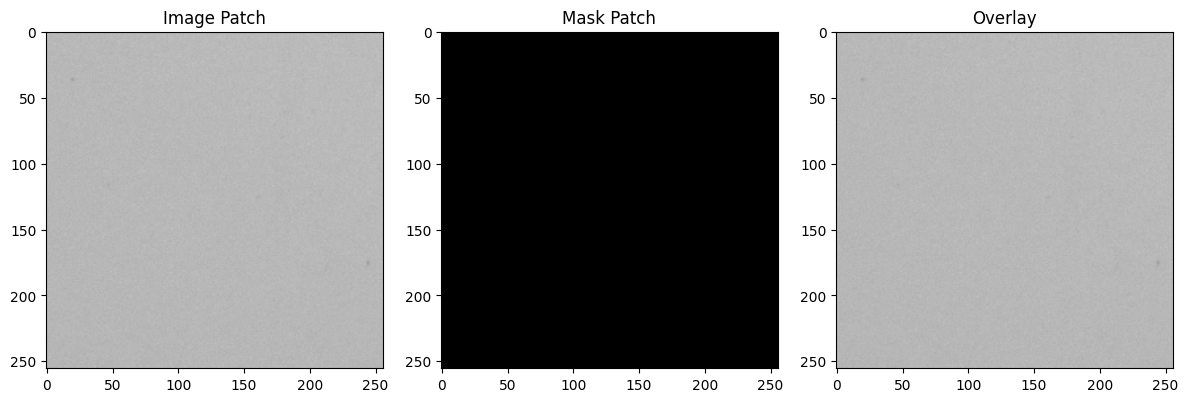

In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from patchify import patchify

# Constants
PATCH_SIZE = 256
DATASET_DIR = "client_data"
OUTPUT_DIR = "dataset_patched"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def detect_and_crop_petri_dish_with_masks(image_path, mask_paths):
    """
    Identifies and crops the Petri dish region from an image and applies the same crop to masks.
    
    Args:
        image_path (str): Path to the image file.
        mask_paths (list): List of paths to associated masks.

    Returns:
        ndarray: Cropped image.
        list: Cropped masks.
    """
    grayscale_image = cv2.imread(image_path, 0)
    original_image = cv2.imread(image_path)

    blurred_image = cv2.medianBlur(grayscale_image, 5)
    _, binary_image = cv2.threshold(blurred_image, 150, 255, cv2.THRESH_BINARY)

    kernel = np.ones((9, 9), np.uint8)
    dilated_image = cv2.dilate(binary_image, kernel, iterations=3)
    processed_image = cv2.erode(dilated_image, kernel, iterations=4)

    contours, _ = cv2.findContours(processed_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None, []

    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)

    square_size = max(w, h)
    x_center, y_center = x + w // 2, y + h // 2
    x_start, y_start = x_center - square_size // 2, y_center - square_size // 2
    x_end, y_end = x_start + square_size, y_start + square_size

    cropped_image = original_image[max(0, y_start):min(grayscale_image.shape[0], y_end), 
                                   max(0, x_start):min(grayscale_image.shape[1], x_end)]

    cropped_masks = [
        cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)[max(0, y_start):min(grayscale_image.shape[0], y_end), 
                                                     max(0, x_start):min(grayscale_image.shape[1], x_end)]
        for mask_path in mask_paths
    ]

    return cropped_image, cropped_masks

def create_patches_and_save(image_dir, mask_dir, output_dir, patch_size, dataset_type):
    """
    Generates and saves patches from images and masks in the dataset.

    Args:
        image_dir (str): Path to the image directory.
        mask_dir (str): Path to the mask directory.
        output_dir (str): Path to save the patches.
        patch_size (int): Size of the patches.
        dataset_type (str): Type of dataset (train or val).
    """
    img_save_dir = os.path.join(output_dir, f"{dataset_type}_images/{dataset_type}")
    mask_save_dir = os.path.join(output_dir, f"{dataset_type}_masks/{dataset_type}")
    os.makedirs(img_save_dir, exist_ok=True)
    os.makedirs(mask_save_dir, exist_ok=True)

    for img_name in tqdm(os.listdir(image_dir)):
        if not img_name.endswith(".png"):
            continue

        if dataset_type == "val" and not img_name.startswith("val_"):
            continue
        if dataset_type == "train" and img_name.startswith("val_"):
            continue

        img_path = os.path.join(image_dir, img_name)
        base_name = img_name[:-4]

        mask_paths = []
        if "Y2B_23" in mask_dir:
            potential_mask = os.path.join(mask_dir, f"{base_name}_root_mask.tif")
            if os.path.exists(potential_mask):
                mask_paths.append(potential_mask)
        elif "Y2B_24" in mask_dir:
            for sub_dir in os.listdir(mask_dir):
                sub_dir_path = os.path.join(mask_dir, sub_dir)
                if os.path.isdir(sub_dir_path):
                    potential_mask = os.path.join(sub_dir_path, f"{base_name}_root_mask.tif")
                    if os.path.exists(potential_mask):
                        mask_paths.append(potential_mask)

        if not mask_paths:
            continue

        cropped_img, cropped_masks = detect_and_crop_petri_dish_with_masks(img_path, mask_paths)

        if cropped_img is None or not cropped_masks:
            continue

        img_height, img_width = cropped_img.shape[:2]
        pad_h, pad_w = (patch_size - img_height % patch_size) % patch_size, (patch_size - img_width % patch_size) % patch_size

        padded_image = np.pad(cropped_img, ((0, pad_h), (0, pad_w), (0, 0)), mode='constant')
        padded_masks = [np.pad(mask, ((0, pad_h), (0, pad_w)), mode='constant') for mask in cropped_masks]

        img_patches = patchify(padded_image, (patch_size, patch_size, 3), step=patch_size)
        mask_patches = [patchify(mask, (patch_size, patch_size), step=patch_size) for mask in padded_masks]

        for i in range(img_patches.shape[0]):
            for j in range(img_patches.shape[1]):
                img_patch = img_patches[i, j, 0]
                combined_mask_patch = np.zeros((patch_size, patch_size), dtype=np.uint8)

                for mask_patch in mask_patches:
                    combined_mask_patch = cv2.bitwise_or(combined_mask_patch, mask_patch[i, j])

                combined_mask_patch = (combined_mask_patch * 255).astype(np.uint8)

                patch_name = f"{base_name}_{i}_{j}.png"

                cv2.imwrite(os.path.join(img_save_dir, patch_name), img_patch)
                cv2.imwrite(os.path.join(mask_save_dir, patch_name), combined_mask_patch)

# Processing datasets
DATASET_Y2B23 = os.path.join(DATASET_DIR, "Y2B_23")
DATASET_Y2B24 = os.path.join(DATASET_DIR, "Y2B_24")

create_patches_and_save(
    os.path.join(DATASET_Y2B23, "images/train"),
    os.path.join(DATASET_Y2B23, "masks"),
    OUTPUT_DIR, PATCH_SIZE, "train"
)

create_patches_and_save(
    os.path.join(DATASET_Y2B23, "images/test"),
    os.path.join(DATASET_Y2B23, "masks"),
    OUTPUT_DIR, PATCH_SIZE, "train"
)

create_patches_and_save(
    os.path.join(DATASET_Y2B24, "images"),
    os.path.join(DATASET_Y2B24, "masks"),
    OUTPUT_DIR, PATCH_SIZE, "train"
)

create_patches_and_save(
    os.path.join(DATASET_Y2B24, "images"),
    os.path.join(DATASET_Y2B24, "masks"),
    OUTPUT_DIR, PATCH_SIZE, "val"
)

# Verification and Visualization
def display_random_patches(output_dir, dataset_type="train"):
    """
    Visualizes random patches from the dataset.

    Args:
        output_dir (str): Path to the processed dataset.
        dataset_type (str): Dataset type ('train' or 'val').
    """
    img_dir = os.path.join(output_dir, f"{dataset_type}_images/{dataset_type}")
    mask_dir = os.path.join(output_dir, f"{dataset_type}_masks/{dataset_type}")

    for _ in range(5):
        random_file = np.random.choice(os.listdir(img_dir))
        img_path = os.path.join(img_dir, random_file)
        mask_path = os.path.join(mask_dir, random_file)

        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        overlay = image.copy()
        overlay[mask > 0] = [0, 255, 0]

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Image Patch")
        axes[1].imshow(mask, cmap="gray")
        axes[1].set_title("Mask Patch")
        axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axes[2].set_title("Overlay")
        plt.tight_layout()
        plt.show()

display_random_patches(OUTPUT_DIR, "train")
display_random_patches(OUTPUT_DIR, "val")
